

> **INSTALL PACKAGE / IMPORT**



In [1]:
!pip install torchmetrics lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00


In [2]:
import os
import torch
from torch import nn, optim
from PIL import Image
from torchvision import transforms
from torchvision.utils import save_image
import torch.nn.functional as F
from torchmetrics.image import PeakSignalNoiseRatio, StructuralSimilarityIndexMeasure
import lpips
import matplotlib.pyplot as plt

**UPLOAD IMAGE**

In [3]:
from google.colab import files

uploaded = files.upload()
print(uploaded.keys())

Saving input2.jpeg to input2.jpeg
dict_keys(['input2.jpeg'])


**VAE MODEL**

In [4]:
class VariationalAutoEncoder(nn.Module):
    def __init__(self, z_dim=32, encoder_channels=[1, 64, 128, 256], hidden_dim=1024):
        super().__init__()

        self.z_dim = z_dim
        self.hidden_dim = hidden_dim
        self.encoder_channels = encoder_channels
        self.decoder_channels = encoder_channels[::-1]

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # Encoder
        self.encoder_layers = nn.ModuleList()

        # 28x28 -> 14x14 -> 7x7 -> 7x7
        for i in range(len(self.encoder_channels) - 1):
            in_ch = self.encoder_channels[i]
            out_ch = self.encoder_channels[i + 1]

            if i < 2:
                self.encoder_layers.append(
                    nn.Conv2d(
                        in_channels=in_ch,
                        out_channels=out_ch,
                        kernel_size=4,
                        stride=2,
                        padding=1
                    )
                )
            else:
                self.encoder_layers.append(
                    nn.Conv2d(
                        in_channels=in_ch,
                        out_channels=out_ch,
                        kernel_size=3,
                        stride=1,
                        padding=1
                    )
                )

        self.final_channels = self.encoder_channels[-1]
        self.feature_map_size = 7

        flattened_dim = self.final_channels * self.feature_map_size * self.feature_map_size

        self.img2hidden = nn.Linear(flattened_dim, hidden_dim)
        self.hidden2mu = nn.Linear(hidden_dim, z_dim)
        self.hidden2logvar = nn.Linear(hidden_dim, z_dim)

        # Decoder
        self.z2hidden = nn.Linear(z_dim, hidden_dim)
        self.hidden2img = nn.Linear(hidden_dim, flattened_dim)

        self.decoder_layers = nn.ModuleList()

        num_decoder_layers = len(self.decoder_channels) - 1

        # 7x7 -> 7x7 -> 14x14 -> 28x28
        for i in range(num_decoder_layers):
            in_ch = self.decoder_channels[i]
            out_ch = self.decoder_channels[i + 1]

            if i < num_decoder_layers - 2:
                self.decoder_layers.append(
                    nn.ConvTranspose2d(
                        in_channels=in_ch,
                        out_channels=out_ch,
                        kernel_size=3,
                        stride=1,
                        padding=1
                    )
                )
            else:
                self.decoder_layers.append(
                    nn.ConvTranspose2d(
                        in_channels=in_ch,
                        out_channels=out_ch,
                        kernel_size=4,
                        stride=2,
                        padding=1
                    )
                )

    def encode(self, x):
        h = x

        for layer in self.encoder_layers:
            h = self.relu(layer(h))

        h = h.reshape(h.size(0), -1)
        h = self.relu(self.img2hidden(h))

        mu = self.hidden2mu(h)
        logvar = self.hidden2logvar(h)

        return mu, logvar

    def decode(self, z):
        h = self.relu(self.z2hidden(z))
        h = self.relu(self.hidden2img(h))

        h = h.reshape(
            z.size(0),
            self.final_channels,
            self.feature_map_size,
            self.feature_map_size
        )

        for i, layer in enumerate(self.decoder_layers):
            h = layer(h)

            if i < len(self.decoder_layers) - 1:
                h = self.relu(h)
            else:
                h = self.sigmoid(h)

        return h

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar, z

**ADJUSTMENTS BEFORE TRAINING**

In [5]:
IMAGE_PATH = "input2.jpeg"
OUTPUT_PATH = "reconstruction.png"
IMAGE_SIZE = 28
Z_DIM = 20
LR = 8e-4
NUM_STEPS = 10000

In [6]:
TARGET_ASCII = 69   # 'A'
PAYLOAD_LOSS_WEIGHT = 0.01
#How significant should payload loss be as a percentage of total loss?

In [7]:
transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

img = Image.open(IMAGE_PATH)
x = transform(img)
x = x.unsqueeze(0)   # (1, 1, 28, 28)

print("Tensor shape:", x.shape)

Tensor shape: torch.Size([1, 1, 28, 28])


**SHOW IMAGE**

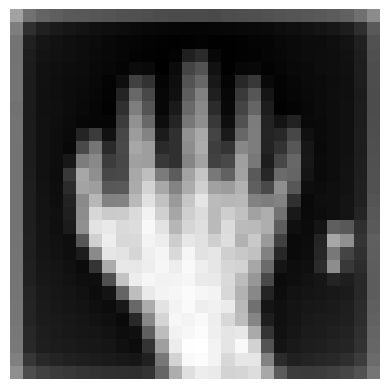

In [8]:
plt.imshow(x.squeeze(0).squeeze(0), cmap="gray")
plt.axis("off")
plt.show()

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

x = x.to(device)
model = VariationalAutoEncoder(z_dim=Z_DIM).to(device)

Using device: cuda


**PAYLOAD DECODER**

In [10]:
class PayloadDecoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256)
        )

    def forward(self, x):
        return self.net(x)

In [11]:
selected_weight = model.hidden2mu.weight
input_dim = selected_weight.numel()

payload_decoder = PayloadDecoder(input_dim).to(device)
payload_loss_fn = nn.CrossEntropyLoss()

print("Selected weight shape:", selected_weight.shape)
print("Payload decoder input dim:", input_dim)

Selected weight shape: torch.Size([20, 1024])
Payload decoder input dim: 20480


**OPTIMIZER, SCHEDULER, METRICS**

In [12]:
optimizer = optim.AdamW(
    list(model.parameters()) + list(payload_decoder.parameters()),
    lr=LR
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1000, gamma=0.8)

lossfn = nn.MSELoss(reduction="sum")
psnr = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# lpips_metric = lpips.LPIPS(net='alex').to(device)

In [13]:
os.makedirs("outputs", exist_ok=True)

**TRAINING**

In [14]:
model.train()
payload_decoder.train()

target_tensor = torch.tensor([TARGET_ASCII], dtype=torch.long, device=device)

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    x_reconstructed, mu, logvar, z = model(x)

    # VAE losses
    recon_loss = lossfn(x_reconstructed, x)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Payload loss from selected weight
    selected_weight = model.hidden2mu.weight
    weight_flat = selected_weight.view(1, -1)

    payload_logits = payload_decoder(weight_flat)
    payload_loss = payload_loss_fn(payload_logits, target_tensor)

    # Total loss
    loss = recon_loss + kl + PAYLOAD_LOSS_WEIGHT * payload_loss

    loss.backward()
    optimizer.step()
    scheduler.step()

    if step % 500 == 0:
        predicted_ascii = torch.argmax(payload_logits, dim=1).item()
        print(
            f"Step {step}: total={loss.item():.4f}, "
            f"recon={recon_loss.item():.4f}, "
            f"kl={kl.item():.4f}, "
            f"payload={payload_loss.item():.4f}, "
            f"pred={predicted_ascii}"
        )

print("Training finished")

Step 0: total=99.6842, recon=99.6233, kl=0.0048, payload=5.6091, pred=226
Step 500: total=0.2918, recon=0.2892, kl=0.0026, payload=0.0000, pred=69
Step 1000: total=0.1417, recon=0.1396, kl=0.0021, payload=0.0000, pred=69
Step 1500: total=0.0412, recon=0.0400, kl=0.0012, payload=0.0000, pred=69
Step 2000: total=0.1401, recon=0.1393, kl=0.0008, payload=0.0000, pred=69
Step 2500: total=0.0346, recon=0.0342, kl=0.0004, payload=0.0000, pred=69
Step 3000: total=0.0282, recon=0.0279, kl=0.0003, payload=0.0000, pred=69
Step 3500: total=0.0668, recon=0.0667, kl=0.0001, payload=0.0000, pred=69
Step 4000: total=0.0340, recon=0.0340, kl=0.0001, payload=0.0000, pred=69
Step 4500: total=0.0188, recon=0.0188, kl=0.0000, payload=0.0000, pred=69
Step 5000: total=0.0332, recon=0.0331, kl=0.0000, payload=0.0000, pred=69
Step 5500: total=0.0192, recon=0.0192, kl=0.0000, payload=0.0000, pred=69
Step 6000: total=0.0467, recon=0.0467, kl=0.0000, payload=0.0000, pred=69
Step 6500: total=0.0133, recon=0.0132, 

**CHECK PAYLOAD RESULT**

In [15]:
payload_decoder.eval()

with torch.no_grad():
    selected_weight = model.hidden2mu.weight
    weight_flat = selected_weight.view(1, -1)
    payload_logits = payload_decoder(weight_flat)

    predicted_ascii = torch.argmax(payload_logits, dim=1).item()

    print("Target ASCII:", TARGET_ASCII)
    print("Predicted ASCII:", predicted_ascii)
    print("Target char:", chr(TARGET_ASCII))
    print("Predicted char:", chr(predicted_ascii))

Target ASCII: 69
Predicted ASCII: 69
Target char: E
Predicted char: E


**RECONSTRUCTION EVALUATION**

In [16]:
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(x)
    x_reconstructed = model.decode(mu)

    comparison = torch.cat([x, x_reconstructed], dim=0)
    save_image(comparison, "outputs/compare_final2.png", nrow=2)

    psnr_value = psnr(x_reconstructed, x)
    ssim_value = ssim(x_reconstructed, x)

    print(f"PSNR: {psnr_value.item():.4f}")
    print(f"SSIM: {ssim_value.item():.4f}")
    print("Payload target:", TARGET_ASCII, chr(TARGET_ASCII))

PSNR: 45.5365
SSIM: 0.9991
Payload target: 69 E


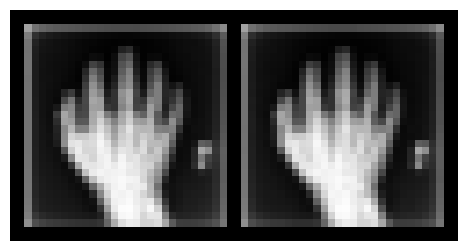

In [17]:
result_img = Image.open("outputs/compare_final2.png")
plt.figure(figsize=(6, 3))
plt.imshow(result_img)
plt.axis("off")
plt.show()

In [14]:
from google.colab import files
files.download("outputs/compare_final2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>